In [24]:
import numpy as np
from io import StringIO

# proliferating e-anyons, m-anyons subthreshold

data_str1 = """ 0.562800 0.586100 0.606400 0.629600 0.639200 0.661400 0.677600 0.689600 0.712700
0.554700 0.585100 0.601500 0.624300 0.638300 0.658400 0.671200 0.695400 0.705300
0.568000 0.588600 0.592800 0.621200 0.636200 0.660800 0.671200 0.691800 0.706300
0.560800 0.581200 0.604900 0.616900 0.640400 0.651100 0.679100 0.689600 0.710900
0.542100 0.569400 0.593400 0.624100 0.634600 0.665100 0.680300 0.704600 0.717700
0.555600 0.560200 0.597300 0.609700 0.632300 0.653500 0.677100 0.695000 0.722500
0.537900 0.565200 0.589800 0.616500 0.635700 0.659100 0.684600 0.701200 0.718900
0.544000 0.565100 0.589100 0.625900 0.638000 0.665600 0.669500 0.699800 0.717800
0.530500 0.557300 0.590900 0.611900 0.637000 0.659200 0.684400 0.705200 0.735900
0.532500 0.565100 0.570000 0.601200 0.632800 0.662600 0.683300 0.707800 0.731800
0.532800 0.554300 0.582700 0.606900 0.633300 0.656900 0.684700 0.707200 0.730800
0.528900 0.558600 0.585200 0.610500 0.636200 0.651100 0.677500 0.714300 0.721800
0.517300 0.548800 0.577600 0.595400 0.639100 0.661600 0.684000 0.704700 0.736300
0.516900 0.545700 0.577200 0.610800 0.629600 0.666600 0.684000 0.720400 0.746100
0.522500 0.541500 0.574900 0.599900 0.637500 0.662000 0.686600 0.715400 0.750500
0.511600 0.550500 0.565400 0.611700 0.637600 0.671500 0.697300 0.717500 0.742700 """
data_str2 = """ 0.552000 0.581200 0.602200 0.622200 0.643200 0.662500 0.682000 0.684400 0.705600
0.566900 0.581700 0.602700 0.618400 0.639500 0.657400 0.678300 0.693800 0.712500
0.572000 0.570200 0.601800 0.610900 0.641600 0.655000 0.675200 0.691300 0.703300
0.563100 0.580600 0.604000 0.619100 0.634000 0.662000 0.675500 0.690200 0.715600
0.543900 0.570800 0.593100 0.609800 0.643500 0.655800 0.682900 0.691400 0.716000
0.542000 0.567200 0.592100 0.612800 0.639700 0.654500 0.677000 0.690200 0.722100
0.541200 0.575700 0.592200 0.612000 0.633800 0.654000 0.685100 0.698900 0.721700
0.543300 0.567500 0.590200 0.605300 0.637900 0.665500 0.682600 0.702100 0.711600
0.531500 0.555100 0.584300 0.609200 0.641600 0.663600 0.679500 0.708000 0.735500
0.538200 0.552900 0.575300 0.606200 0.641500 0.654800 0.683700 0.708800 0.731500
0.528500 0.561300 0.573400 0.605600 0.627100 0.661300 0.678400 0.707800 0.734800
0.526000 0.558400 0.592900 0.610000 0.630100 0.664800 0.688400 0.712500 0.720900
0.511300 0.549500 0.579800 0.608400 0.639700 0.654200 0.690000 0.711200 0.741300
0.511200 0.548400 0.568500 0.605800 0.639000 0.665100 0.692800 0.710800 0.735900
0.505700 0.548500 0.573900 0.608300 0.632600 0.650700 0.686700 0.718800 0.740700
0.512700 0.547100 0.569700 0.603900 0.636000 0.663700 0.684200 0.719200 0.739300 """
data_str3 = """ 0.561200 0.585000 0.602900 0.629800 0.643300 0.652400 0.679700 0.687800 0.705900
0.565500 0.585400 0.595400 0.620800 0.641600 0.656100 0.675800 0.689300 0.709700
0.562600 0.579700 0.603300 0.618900 0.634300 0.657200 0.677500 0.688200 0.706700
0.565000 0.575900 0.607100 0.620800 0.636400 0.660200 0.679100 0.698700 0.714500
0.542900 0.574400 0.593400 0.623500 0.636700 0.649000 0.679200 0.697700 0.725300
0.546700 0.570600 0.588400 0.615800 0.635800 0.661900 0.680300 0.702100 0.718500
0.545700 0.567600 0.592500 0.623700 0.639300 0.652100 0.683000 0.698700 0.714500
0.545600 0.570600 0.584800 0.618900 0.644900 0.655100 0.686400 0.700400 0.717800
0.530800 0.553400 0.583700 0.610400 0.637600 0.660300 0.682700 0.699100 0.735800
0.533200 0.560200 0.571200 0.612500 0.642200 0.662800 0.685800 0.705300 0.723500
0.520300 0.552600 0.572100 0.611100 0.629700 0.653600 0.685800 0.705100 0.727500
0.526200 0.557300 0.588600 0.603300 0.632300 0.657400 0.692000 0.706400 0.723600
0.508500 0.546200 0.575100 0.598400 0.636500 0.670800 0.680100 0.715500 0.744600
0.521000 0.543900 0.580000 0.600100 0.628400 0.665800 0.688100 0.717000 0.734300
0.507500 0.543800 0.572800 0.603500 0.633000 0.662900 0.672600 0.708000 0.747500
0.523100 0.549200 0.576800 0.598400 0.645200 0.666800 0.691900 0.717000 0.737100 """
data_str4 = """ 0.557600 0.578000 0.615500 0.625200 0.642000 0.664500 0.685000 0.696700 0.709100
0.561100 0.590100 0.606100 0.611500 0.633100 0.652700 0.674100 0.686600 0.706100
0.561900 0.581400 0.609700 0.621100 0.650600 0.662900 0.670900 0.694500 0.702900
0.568200 0.586300 0.601600 0.618700 0.635300 0.664700 0.673500 0.688600 0.702000
0.555800 0.564100 0.596200 0.611300 0.638700 0.656400 0.674800 0.704100 0.719400
0.537200 0.577100 0.595200 0.618100 0.641500 0.662100 0.692000 0.700000 0.717400
0.542900 0.567300 0.596700 0.618400 0.647400 0.657300 0.673300 0.699300 0.717000
0.550900 0.570200 0.587700 0.614800 0.643100 0.658900 0.675600 0.703000 0.715400
0.517900 0.555100 0.577700 0.606800 0.631300 0.655900 0.683600 0.706700 0.736700
0.536400 0.561600 0.585000 0.610600 0.630500 0.659900 0.675800 0.707500 0.728100
0.520900 0.559200 0.583500 0.615200 0.639500 0.653000 0.689000 0.706200 0.731300
0.531900 0.556500 0.576000 0.599300 0.635700 0.667200 0.685600 0.703200 0.734800
0.511500 0.544200 0.574700 0.606500 0.627100 0.662200 0.688300 0.717700 0.737900
0.515700 0.554100 0.570800 0.605400 0.632500 0.670300 0.691000 0.716400 0.734300
0.527200 0.544500 0.572900 0.609300 0.638000 0.664000 0.685900 0.718100 0.737300
0.516100 0.543600 0.576900 0.612600 0.631700 0.659500 0.689700 0.711500 0.737300 """
data_str5 = """ 0.562100 0.586300 0.598600 0.631700 0.638000 0.656900 0.665100 0.688400 0.704300
0.562500 0.575300 0.597100 0.617900 0.640400 0.660500 0.675200 0.706300 0.714700
0.573300 0.580700 0.610800 0.625500 0.633900 0.663000 0.675900 0.702900 0.701100
0.561100 0.585200 0.598600 0.623600 0.637600 0.652400 0.682700 0.697400 0.705300
0.541100 0.566700 0.591100 0.609200 0.629100 0.653400 0.675600 0.705500 0.720000
0.544200 0.571800 0.587300 0.615900 0.632400 0.657700 0.675500 0.702000 0.715700
0.544900 0.573300 0.592300 0.611100 0.637100 0.659800 0.678600 0.687900 0.718900
0.544200 0.557600 0.594300 0.613500 0.629200 0.652500 0.677800 0.689300 0.728800
0.528100 0.560900 0.592100 0.616100 0.631300 0.659100 0.679400 0.705000 0.730000
0.525300 0.551600 0.580200 0.598600 0.636600 0.653900 0.696900 0.712400 0.730500
0.533100 0.553600 0.590000 0.604400 0.627700 0.651600 0.676900 0.701900 0.732300
0.532500 0.558200 0.584700 0.611000 0.630800 0.652400 0.696600 0.701100 0.734300
0.514300 0.554400 0.576100 0.603700 0.642600 0.670400 0.684500 0.722500 0.744700
0.516400 0.541900 0.567200 0.605100 0.632000 0.666400 0.689000 0.715300 0.736200
0.514200 0.546100 0.572200 0.606400 0.638000 0.663600 0.682400 0.708800 0.738300
0.515300 0.560700 0.568100 0.611300 0.631700 0.671200 0.692200 0.717700 0.737800 """
data_str6 = """ 0.569300 0.579600 0.601600 0.619300 0.640900 0.655700 0.682000 0.687100 0.699900
0.568000 0.578100 0.600400 0.618800 0.639400 0.665100 0.674500 0.681700 0.707800
0.558500 0.592200 0.593500 0.621900 0.639300 0.658900 0.677300 0.684300 0.704200
0.561300 0.577300 0.599300 0.615300 0.640300 0.656400 0.681100 0.688000 0.715900
0.536800 0.573600 0.591700 0.616600 0.632000 0.653300 0.681400 0.698900 0.719400
0.543000 0.560400 0.587500 0.609800 0.632400 0.649300 0.680800 0.696300 0.715200
0.541400 0.575800 0.593200 0.613000 0.635300 0.657600 0.681500 0.701600 0.723200
0.548600 0.572300 0.580700 0.618800 0.634000 0.660600 0.678700 0.698000 0.715200
0.531300 0.550800 0.577700 0.612500 0.632600 0.654200 0.684200 0.715900 0.725300
0.538200 0.558000 0.585900 0.600500 0.631200 0.659400 0.682000 0.707600 0.726900
0.526000 0.562400 0.587900 0.614400 0.628700 0.658500 0.687400 0.711700 0.726400
0.534100 0.562600 0.581600 0.609900 0.627400 0.660100 0.674900 0.703400 0.729700
0.506200 0.550100 0.567600 0.600700 0.641800 0.659900 0.678300 0.717700 0.732500
0.510700 0.547800 0.580300 0.596600 0.633500 0.667900 0.681700 0.720200 0.743900
0.519900 0.546300 0.574300 0.606200 0.635300 0.664000 0.689600 0.718400 0.740600
0.519600 0.548200 0.572100 0.605600 0.643900 0.665600 0.682200 0.717100 0.744500 """
data_str7 = """ 0.561800 0.598100 0.602800 0.619400 0.646200 0.660600 0.678200 0.697100 0.710500
0.571500 0.585400 0.602800 0.632400 0.639800 0.649900 0.673400 0.684000 0.710700
0.563300 0.589900 0.606600 0.617900 0.645400 0.664600 0.676300 0.700100 0.710400
0.562300 0.590000 0.599000 0.618100 0.633400 0.651300 0.668500 0.692300 0.712100
0.538400 0.560100 0.583200 0.617500 0.628700 0.653100 0.678300 0.698400 0.714400
0.544000 0.576400 0.594500 0.609500 0.635400 0.665300 0.669600 0.704000 0.715700
0.538400 0.573600 0.593700 0.611500 0.636100 0.659000 0.679400 0.697100 0.712500
0.547800 0.567700 0.598900 0.617500 0.623300 0.663300 0.679900 0.698900 0.715500
0.530800 0.548600 0.583000 0.598900 0.639900 0.652200 0.682000 0.703100 0.735200
0.535800 0.560200 0.581400 0.605400 0.634500 0.663700 0.679900 0.710100 0.730000
0.531400 0.557500 0.584600 0.610100 0.641800 0.660700 0.679300 0.708700 0.725500
0.524100 0.566300 0.588500 0.610100 0.641700 0.656200 0.683200 0.710400 0.729900
0.518000 0.547100 0.581800 0.602000 0.641400 0.661700 0.691400 0.718200 0.738000
0.514500 0.548500 0.574700 0.605600 0.635600 0.659600 0.689900 0.716300 0.732500
0.511700 0.554100 0.570000 0.604500 0.634500 0.657900 0.691200 0.718100 0.737700
0.512700 0.557100 0.577400 0.600900 0.634900 0.666600 0.691700 0.716600 0.741700 """
data_str8 = """ 0.574900 0.575400 0.608100 0.616900 0.643800 0.658100 0.670000 0.690700 0.707200
0.566500 0.593700 0.595700 0.632600 0.637400 0.658900 0.675900 0.694000 0.712300
0.565500 0.585200 0.598600 0.623300 0.636800 0.662700 0.678000 0.692300 0.717700
0.562500 0.585300 0.605300 0.619000 0.629200 0.656400 0.671000 0.693200 0.707100
0.536600 0.566200 0.591000 0.614600 0.627400 0.661100 0.672600 0.703700 0.721000
0.543800 0.563100 0.604200 0.619100 0.642000 0.656600 0.685100 0.696500 0.717300
0.552200 0.568000 0.591800 0.611600 0.631400 0.656100 0.678200 0.702300 0.715900
0.547900 0.574100 0.587900 0.617300 0.641100 0.660700 0.682700 0.704700 0.720000
0.541300 0.558800 0.577700 0.616800 0.631400 0.666000 0.689600 0.706500 0.730600
0.526100 0.557300 0.598200 0.611300 0.631500 0.659600 0.674200 0.699700 0.731000
0.532400 0.549000 0.580200 0.614700 0.640700 0.664600 0.687400 0.702400 0.731500
0.531100 0.556600 0.575900 0.607100 0.638700 0.657400 0.674000 0.705000 0.735800
0.523200 0.539800 0.575400 0.598600 0.649500 0.666700 0.688800 0.710600 0.736000
0.520500 0.546100 0.582600 0.606800 0.633300 0.669900 0.686100 0.715700 0.747800
0.514700 0.542700 0.583900 0.603900 0.631100 0.655600 0.691700 0.717000 0.734000
0.512700 0.535100 0.571500 0.595300 0.621500 0.666300 0.690600 0.716200 0.733300 """
data_str9 = """ 0.567500 0.578000 0.597600 0.617400 0.633600 0.657700 0.676000 0.699900 0.709400
0.567700 0.580700 0.586400 0.624700 0.638500 0.659500 0.669200 0.688600 0.705900
0.557600 0.582700 0.605300 0.624400 0.639300 0.656500 0.674300 0.692800 0.710500
0.575000 0.583600 0.604200 0.622300 0.638900 0.656200 0.663000 0.694000 0.701200
0.543400 0.564600 0.590600 0.609000 0.642600 0.656500 0.683300 0.691000 0.714400
0.544400 0.561300 0.592500 0.614500 0.638000 0.655000 0.688700 0.696800 0.718300
0.555400 0.565800 0.591100 0.615900 0.634300 0.661500 0.683200 0.696600 0.718400
0.550600 0.566500 0.592100 0.616600 0.638500 0.659800 0.686600 0.696900 0.725200
0.531800 0.553900 0.581700 0.606900 0.636600 0.660800 0.677300 0.704600 0.725200
0.536600 0.552700 0.577800 0.612100 0.636600 0.657300 0.683500 0.706700 0.732700
0.535700 0.555100 0.588000 0.605600 0.632400 0.661600 0.683600 0.709600 0.733700
0.530000 0.554200 0.581400 0.606200 0.637600 0.662600 0.683800 0.712900 0.725300
0.508700 0.547900 0.576400 0.609900 0.625100 0.660400 0.689400 0.713500 0.736800
0.519100 0.548400 0.572700 0.597300 0.634000 0.664100 0.685500 0.723000 0.739700
0.510800 0.539700 0.573300 0.593300 0.639800 0.665300 0.690200 0.716700 0.742200
0.514200 0.550700 0.567700 0.594900 0.636000 0.652300 0.687300 0.716700 0.730200 """
data_str10= """ 0.577700 0.580700 0.598600 0.622200 0.639900 0.656100 0.680100 0.687800 0.714600
0.559900 0.587400 0.596200 0.632200 0.643700 0.658400 0.670400 0.694000 0.709200
0.561500 0.584300 0.600200 0.617200 0.632500 0.654700 0.679100 0.698800 0.719400
0.558900 0.577900 0.610300 0.628500 0.633200 0.658800 0.670600 0.692300 0.710400
0.546500 0.562000 0.597800 0.613700 0.633600 0.661200 0.679700 0.708300 0.732700
0.540400 0.569800 0.592800 0.612700 0.633000 0.653200 0.673500 0.695600 0.716200
0.541500 0.569600 0.593900 0.612800 0.634700 0.659700 0.680400 0.703300 0.720000
0.537200 0.571400 0.600000 0.612100 0.642400 0.648000 0.677000 0.700900 0.718700
0.523900 0.550600 0.584500 0.611300 0.643200 0.659400 0.692100 0.710100 0.728800
0.533900 0.556100 0.587100 0.605300 0.635900 0.658500 0.684000 0.710000 0.732500
0.528200 0.555800 0.589800 0.609500 0.634600 0.660800 0.682400 0.707800 0.723300
0.536700 0.552000 0.581000 0.596800 0.638500 0.665600 0.687100 0.704400 0.725300
0.511600 0.544700 0.576500 0.597300 0.637900 0.666500 0.692000 0.712800 0.736700
0.514700 0.552400 0.573800 0.603500 0.629900 0.652100 0.684800 0.716700 0.742800
0.520500 0.548900 0.578600 0.614700 0.634600 0.672100 0.686000 0.716800 0.740700
0.524100 0.543100 0.581100 0.607900 0.636900 0.660500 0.690100 0.715400 0.742900 """

run1 = np.loadtxt(StringIO(data_str1))
run2 = np.loadtxt(StringIO(data_str2))
run3 = np.loadtxt(StringIO(data_str3))
run4 = np.loadtxt(StringIO(data_str4))
run5 = np.loadtxt(StringIO(data_str5))
run6 = np.loadtxt(StringIO(data_str6))
run7 = np.loadtxt(StringIO(data_str7))
run8 = np.loadtxt(StringIO(data_str8))
run9 = np.loadtxt(StringIO(data_str9))
run10= np.loadtxt(StringIO(data_str10))

runs = np.stack([run1, run2, run3, run4, run5, run6, run7, run8, run9, run10])

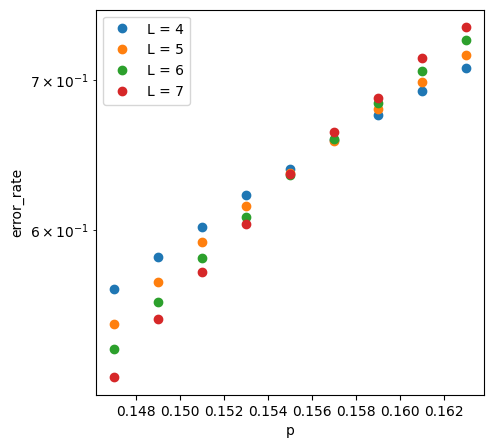

In [25]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

p = [0.147, 0.149, 0.151, 0.153, 0.155, 0.157, 0.159, 0.161, 0.163]
L = [4, 5, 6, 7]

error_rate = np.array([np.mean(runs[:, 0:4, :], axis=(0, 1)),
                       np.mean(runs[:, 4:8, :], axis=(0, 1)),
                       np.mean(runs[:, 8:12, :], axis=(0, 1)),
                       np.mean(runs[:, 12:16, :], axis=(0, 1))])

plt.figure(figsize=(5, 5))
for l in range(len(L)):
    plt.plot(p, error_rate[l], 'o', label=f'L = {L[l]}')
    
plt.yscale('log')
plt.xlabel('p')
plt.ylabel('error_rate')
plt.legend()
plt.show()

In [26]:
from scipy.optimize import curve_fit

p = np.tile(np.array([0.147, 0.149, 0.151, 0.153, 0.155, 0.157, 0.159, 0.161, 0.163]), 4)
L = np.repeat(np.array([4,5,6,7]), 9)
rate = error_rate.flatten()
n = 8000
rate_error = np.array([])
for i in range(len(p)):
    se = (rate[i]*(1-rate[i])/n)**(1/2)
    rate_error = np.append(rate_error, se)

In [27]:
# Define the model
def model(pL, pc, nu, A, B, C):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, full_output=True, sigma=rate_error, absolute_sigma=True)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

Fitted parameters: [ 0.15606333  1.2998241   0.64839785  3.10470167 -5.14333504]
Parameter standard deviations: [5.26371888e-04 1.26155678e-01 5.90183579e-03 4.03168031e-01
 2.96084856e+00]


np.float64(5.945236929270312)

In [28]:
# Define the model
def model(pL, pc, nu, A, B, C, D):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu)) + D*((p-pc)**3)*(L**(3/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, p0=[0.2, 1.5, 0.25, 0, 0, 0], full_output=True, sigma=rate_error, absolute_sigma=True)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

Fitted parameters: [  0.1560446    1.27096975   0.64830397   3.04760397  -5.39931048
 -48.53329302]
Parameter standard deviations: [5.21202325e-04 1.45643632e-01 5.88315142e-03 4.32958666e-01
 2.90750561e+00 1.22227913e+02]


np.float64(5.453113641299405)

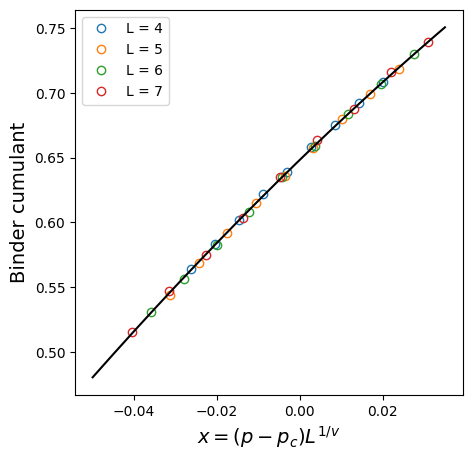

In [33]:
pc = 0.15606333
nu = 1.2998241
A = 0.64839785
B = 3.10470167
C = -5.14333504
# D = -149.66927112
p = [0.147, 0.149, 0.151, 0.153, 0.155, 0.157, 0.159, 0.161, 0.163]
L = [4, 5, 6, 7]
error_rate = np.array([np.mean(runs[:, 0:4, :], axis=(0, 1)),
                       np.mean(runs[:, 4:8, :], axis=(0, 1)),
                       np.mean(runs[:, 8:12, :], axis=(0, 1)),
                       np.mean(runs[:, 12:16, :], axis=(0, 1))])

x = np.zeros((len(L), len(p)))
plt.figure(figsize=(5, 5))
for l in range(len(L)):
    for i in range(len(p)):
        x[l][i] = (p[i]-pc) * (L[l]**(1/nu))
    plt.plot(x[l], error_rate[l], 'o', markerfacecolor='none', label=f'L = {L[l]}')
x_data = np.linspace(-0.05, 0.035, 1000)
y_data = A + B*x_data + C*(x_data**2) #+D*(x_data**3)
plt.plot(x_data, y_data, color = 'k')

#ax = plt.gca()
#ax.spines['top'].set_visible(False)
#ax.spines['right'].set_visible(False)

#plt.yscale('log')
plt.xlabel('$x=(p-p_c)L^{1/v}$', fontsize=14)
plt.ylabel('Binder cumulant', fontsize=14)
plt.legend()
#plt.savefig('modified-D4.png', dpi=600, bbox_inches='tight')
plt.show()